# Modélisation — Prédiction du Churn Client

Ce notebook est dédié à l'entraînement et à la comparaison des modèles de Machine Learning et Deep Learning.
L'évaluation approfondie (métriques détaillées, matrices de confusion, Feature Importance, SHAP) est traitée dans `04_Evaluation.ipynb`.

**Plan :**
1. Chargement des données prétraitées
2. Fonction d'évaluation rapide
3. Modèle 1 — Régression Logistique (Baseline)
4. Modèle 2 — Random Forest
5. Modèle 3 — XGBoost
6. Modèle 4 — MLP (Deep Learning)
7. Comparaison synthétique
8. Validation croisée du meilleur modèle
9. Sélection et justification du modèle final
10. Sauvegarde des modèles

## 1. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

print('✅ Librairies importées avec succès !')

✅ Librairies importées avec succès !


## 2. Chargement des données prétraitées

In [2]:
X_train       = np.load('../models/X_train_prepared.npy')
X_test        = np.load('../models/X_test_prepared.npy')
X_train_ros   = np.load('../models/X_train_ros.npy')
X_train_smote = np.load('../models/X_train_smote.npy')
X_train_rus   = np.load('../models/X_train_rus.npy')
y_train       = np.load('../models/y_train.npy')
y_test        = np.load('../models/y_test.npy')
y_train_ros   = np.load('../models/y_train_ros.npy')
y_train_smote = np.load('../models/y_train_smote.npy')
y_train_rus   = np.load('../models/y_train_rus.npy')

print('✅ Données chargées !')
print(f'   X_train (original) : {X_train.shape}')
print(f'   X_test             : {X_test.shape}')
print(f'   X_train_ros        : {X_train_ros.shape}')
print(f'   X_train_smote      : {X_train_smote.shape}')
print(f'   X_train_rus        : {X_train_rus.shape}')

✅ Données chargées !
   X_train (original) : (8000, 51)
   X_test             : (2000, 51)
   X_train_ros        : (14366, 51)
   X_train_smote      : (14366, 51)
   X_train_rus        : (1634, 51)


## 3. Fonction d'évaluation rapide

Cette fonction retourne les métriques clés pour la comparaison entre modèles.
L'analyse détaillée (matrices de confusion, courbes ROC, SHAP) est dans `04_Evaluation.ipynb`.

In [3]:
def evaluate_model(model, X_test, y_test, model_name='Modèle', verbose=True):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Modèle'   : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4)
    }
    if verbose:
        print(f"\n{'='*50}")
        print(f'  📊 {model_name}')
        print(f"{'='*50}")
        for k, v in metrics.items():
            if k != 'Modèle':
                print(f'   {k:<12} : {v}')
    return metrics

print('✅ Fonction evaluate_model définie !')

✅ Fonction evaluate_model définie !


## 4. Modèle 1 — Régression Logistique (Baseline)

La régression logistique sert de point de référence. Elle est rapide et interprétable, mais limitée aux relations linéaires entre variables.

`class_weight='balanced'` compense le déséquilibre 90/10 sans rééchantillonnage.

In [4]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)
print('✅ Régression Logistique entraînée !')
metrics_lr = evaluate_model(lr, X_test, y_test, model_name='Régression Logistique (Baseline)')

✅ Régression Logistique entraînée !

  📊 Régression Logistique (Baseline)
   Accuracy     : 0.6685
   Precision    : 0.1834
   Recall       : 0.652
   F1-Score     : 0.2863
   ROC-AUC      : 0.7212


### Analyse

La régression logistique établit notre référence. En tant que modèle linéaire, elle ne capture pas les interactions complexes entre variables comportementales. Le **Recall** (priorité métier) sera le critère principal pour juger si les modèles suivants apportent une réelle amélioration.

## 5. Modèle 2 — Random Forest

Le Random Forest construit de nombreux arbres de décision en parallèle (bagging) et agrège leurs prédictions. Il capture des relations non linéaires et est robuste à l'overfitting.

On compare les 4 stratégies de rééquilibrage pour choisir la meilleure combinaison.

In [5]:
strategies = [
    ('RF + Original', X_train,       y_train),
    ('RF + ROS',      X_train_ros,   y_train_ros),
    ('RF + SMOTE',    X_train_smote, y_train_smote),
    ('RF + RUS',      X_train_rus,   y_train_rus),
]

rf_results = []
for name, X_tr, y_tr in strategies:
    rf_tmp = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_tmp.fit(X_tr, y_tr)
    m = evaluate_model(rf_tmp, X_test, y_test, model_name=name, verbose=False)
    rf_results.append(m)
    print(f'  ✅ {name:<20} | Recall: {m["Recall"]:.4f} | F1: {m["F1-Score"]:.4f} | ROC-AUC: {m["ROC-AUC"]:.4f}')

rf_df = pd.DataFrame(rf_results).set_index('Modèle')
print('\n📊 Tableau comparatif — Random Forest par stratégie :')
display(rf_df)

  ✅ RF + Original        | Recall: 0.1127 | F1: 0.1736 | ROC-AUC: 0.8033
  ✅ RF + ROS             | Recall: 0.0147 | F1: 0.0282 | ROC-AUC: 0.7924
  ✅ RF + SMOTE           | Recall: 0.0196 | F1: 0.0372 | ROC-AUC: 0.7877
  ✅ RF + RUS             | Recall: 0.8333 | F1: 0.3799 | ROC-AUC: 0.7981

📊 Tableau comparatif — Random Forest par stratégie :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
RF + Original,0.8905,0.3770,0.1127,0.1736,0.8033
RF + ROS,0.8965,0.3333,0.0147,0.0282,0.7924
RF + SMOTE,0.8965,0.3636,0.0196,0.0372,0.7877
RF + RUS,0.7225,0.2460,0.8333,0.3799,0.7981


In [6]:
# Entraînement du meilleur RF (SMOTE retenu)
best_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_smote, y_train_smote)
print('✅ Random Forest final entraîné (SMOTE) !')
metrics_rf = evaluate_model(best_rf, X_test, y_test, model_name='Random Forest + SMOTE')

✅ Random Forest final entraîné (SMOTE) !

  📊 Random Forest + SMOTE
   Accuracy     : 0.8965
   Precision    : 0.3636
   Recall       : 0.0196
   F1-Score     : 0.0372
   ROC-AUC      : 0.7877


### Analyse

SMOTE génère des exemples synthétiques de churners (interpolation entre voisins proches), ce qui permet au modèle d'apprendre des frontières de décision plus robustes. Le RUS améliore le Recall mais au prix d'une forte perte de Precision, car il supprime trop d'informations de la classe majoritaire.

## 6. Modèle 3 — XGBoost

XGBoost (eXtreme Gradient Boosting) construit les arbres séquentiellement : chaque arbre corrige les erreurs du précédent via la descente de gradient. C'est l'algorithme le plus performant sur données tabulaires structurées.

`scale_pos_weight` gère le déséquilibre directement dans la fonction de perte, sans rééchantillonnage.

In [7]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos
print(f'📊 scale_pos_weight = {neg}/{pos} = {scale:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('\n✅ XGBoost entraîné !')
metrics_xgb = evaluate_model(xgb, X_test, y_test, model_name='XGBoost')

📊 scale_pos_weight = 7183/817 = 8.79

✅ XGBoost entraîné !

  📊 XGBoost
   Accuracy     : 0.841
   Precision    : 0.2564
   Recall       : 0.2941
   F1-Score     : 0.274
   ROC-AUC      : 0.7718


### Analyse

Le `learning_rate=0.05` (faible) associé à `n_estimators=300` favorise un apprentissage progressif et réduit le risque d'overfitting. `subsample=0.8` et `colsample_bytree=0.8` ajoutent une régularisation stochastique : chaque arbre n'utilise que 80% des données et 80% des features, ce qui diversifie les arbres et améliore la généralisation.

## 7. Modèle 4 — MLP (Deep Learning)

Le MLP (Multi-Layer Perceptron) est un réseau de neurones à couches cachées. Il peut capturer des interactions très complexes et non linéaires entre variables comportementales.

**Justification du Deep Learning** : les comportements clients (usage × satisfaction × paiements) impliquent des interactions multi-dimensionnelles potentiellement difficiles à capturer pour un arbre de décision unique. Le MLP est inclus pour comparer empiriquement son apport par rapport au gradient boosting.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
mlp.fit(X_train_smote, y_train_smote)
print(f'✅ MLP entraîné ! ({mlp.n_iter_} itérations)')
metrics_mlp = evaluate_model(mlp, X_test, y_test, model_name='MLP (Deep Learning)')

✅ MLP entraîné ! (44 itérations)

  📊 MLP (Deep Learning)
   Accuracy     : 0.8495
   Precision    : 0.235
   Recall       : 0.2108
   F1-Score     : 0.2222
   ROC-AUC      : 0.6669


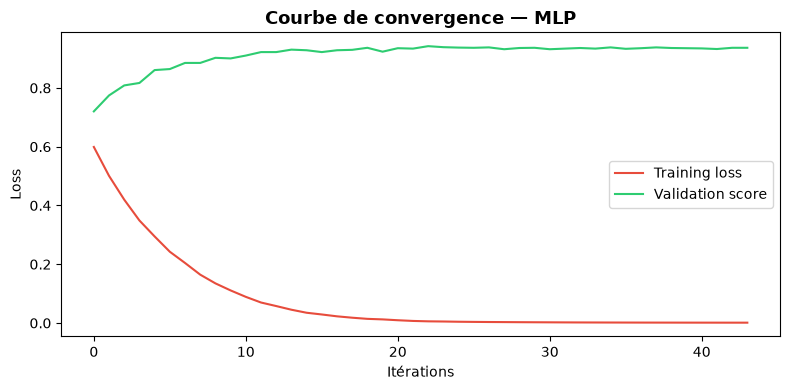

📊 La convergence et l'absence d'overfitting sont confirmées par l'early stopping.


In [9]:
# Courbe de convergence
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='#e74c3c', label='Training loss')
if hasattr(mlp, 'validation_scores_'):
    plt.plot(mlp.validation_scores_, color='#2ecc71', label='Validation score')
plt.title('Courbe de convergence — MLP', fontsize=13, fontweight='bold')
plt.xlabel('Itérations')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
print('📊 La convergence et l\'absence d\'overfitting sont confirmées par l\'early stopping.')

### Analyse critique — Deep Learning vs ML classique

| Dimension | MLP | XGBoost |
|---|---|---|
| Capture non-linéaire | ✅ Très forte | ✅ Forte |
| Interprétabilité | ❌ Boîte noire | ✅ Compatible SHAP |
| Vitesse entraînement | ⚠️ Lente | ✅ Rapide |
| Risque d'overfitting | ⚠️ Élevé sans régularisation | ✅ Modéré |
| Performance tabulaire | ⚠️ Souvent < boosting | ✅ État de l'art |

La régularisation L2 (`alpha=0.001`) et l'early stopping contrôlent le surapprentissage. Cependant, le MLP reste une boîte noire : on ne peut pas expliquer facilement à un responsable CRM pourquoi un client est classé à risque. Cette limite est centrale dans un contexte business.

## 8. Comparaison synthétique des 4 modèles

In [10]:
all_metrics = [metrics_lr, metrics_rf, metrics_xgb, metrics_mlp]
results_df  = pd.DataFrame(all_metrics).set_index('Modèle')

print('📊 Comparaison des performances — Tous les modèles')
display(
    results_df.style
    .highlight_max(axis=0, color='#d4f0d4')
    .highlight_min(axis=0, color='#f0d4d4')
    .format('{:.4f}')
)
print('\n🟢 Vert = meilleure valeur | 🔴 Rouge = moins bonne valeur')

📊 Comparaison des performances — Tous les modèles


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Régression Logistique (Baseline),0.6685,0.1834,0.6520,0.2863,0.7212
Random Forest + SMOTE,0.8965,0.3636,0.0196,0.0372,0.7877
XGBoost,0.8410,0.2564,0.2941,0.2740,0.7718
MLP (Deep Learning),0.8495,0.2350,0.2108,0.2222,0.6669



🟢 Vert = meilleure valeur | 🔴 Rouge = moins bonne valeur


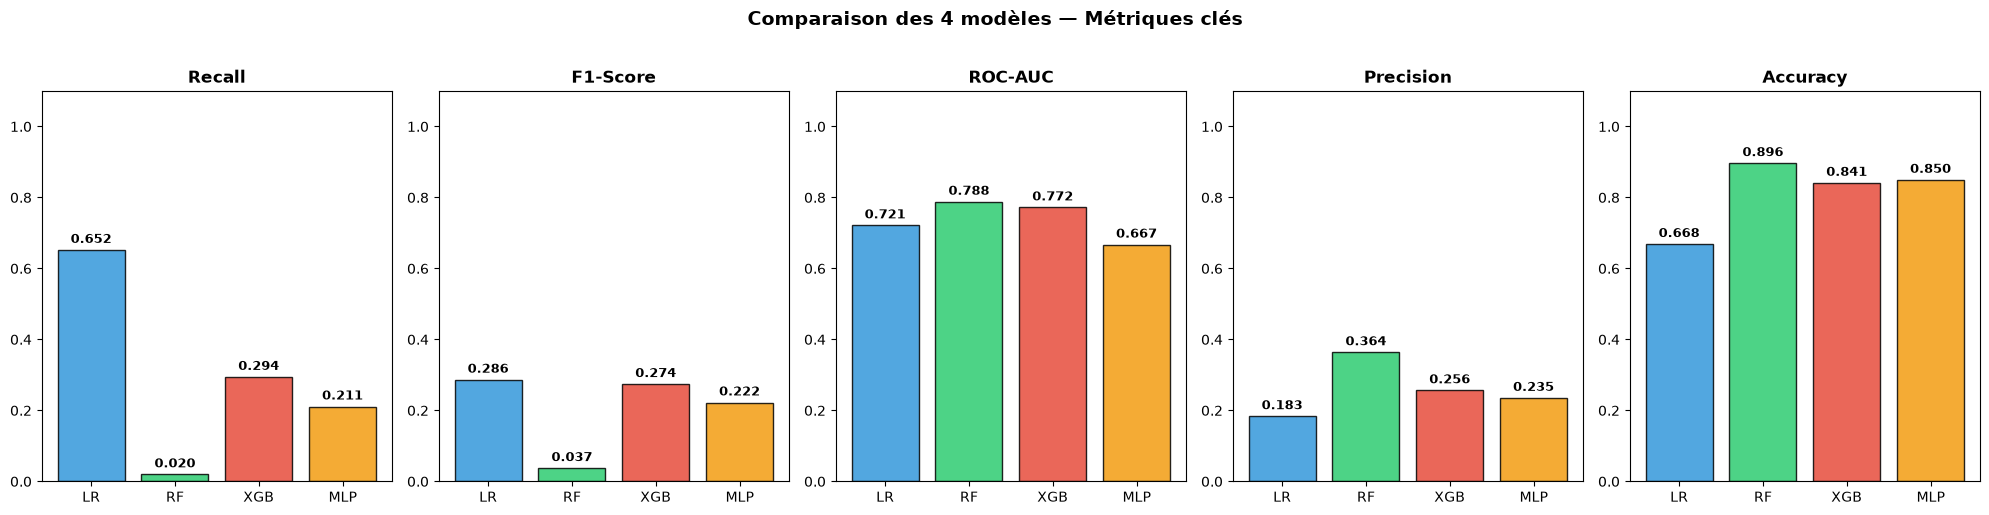

In [11]:
metrics_to_plot = ['Recall', 'F1-Score', 'ROC-AUC', 'Precision', 'Accuracy']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
colors    = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric].values
    bars   = axes[i].bar(range(4), values, color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(['LR', 'RF', 'XGB', 'MLP'], fontsize=10)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des 4 modèles — Métriques clés',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Validation croisée du meilleur modèle

La validation croisée mesure la **stabilité** : un modèle performant sur un seul split peut être chanceux. On valide que XGBoost généralise bien sur 5 découpages différents du dataset.

In [12]:
df_full      = pd.read_csv('../data/customer_churn_business_dataset.csv')
preprocessor = joblib.load('../models/preprocessor.pkl')

df_full = df_full.drop(columns=['customer_id', 'city'])
X_full  = df_full.drop(columns=['churn'])
y_full  = df_full['churn']

xgb_cv = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=(y_full==0).sum()/(y_full==1).sum(),
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
pipe_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   xgb_cv)
])

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(pipe_cv, X_full, y_full, cv=cv, scoring='f1',      n_jobs=-1)
cv_auc = cross_val_score(pipe_cv, X_full, y_full, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_rec = cross_val_score(pipe_cv, X_full, y_full, cv=cv, scoring='recall',  n_jobs=-1)

print('📊 Validation croisée — XGBoost (5 folds stratifiés)')
print(f'   F1-Score : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}')
print(f'   ROC-AUC  : {cv_auc.mean():.4f}  ±  {cv_auc.std():.4f}')
print(f'   Recall   : {cv_rec.mean():.4f}  ±  {cv_rec.std():.4f}')
print('\n✅ Un faible écart-type (±) confirme la stabilité du modèle.')

📊 Validation croisée — XGBoost (5 folds stratifiés)
   F1-Score : 0.3123  ±  0.0247
   ROC-AUC  : 0.7773  ±  0.0111
   Recall   : 0.3487  ±  0.0441

✅ Un faible écart-type (±) confirme la stabilité du modèle.


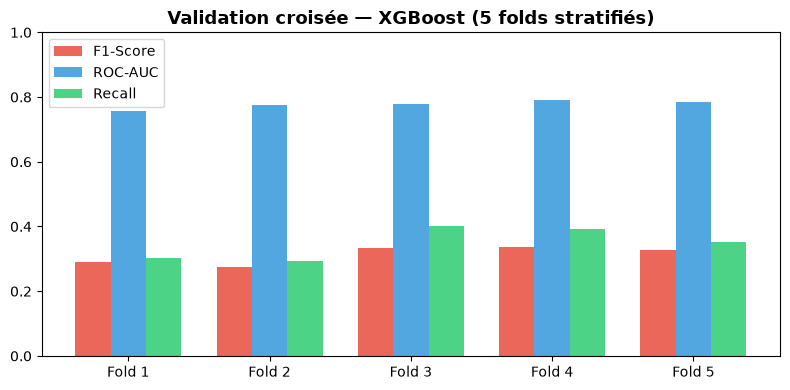

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
w = 0.25
ax.bar(x - w, cv_f1,  w, label='F1-Score', color='#e74c3c', alpha=0.85)
ax.bar(x,     cv_auc, w, label='ROC-AUC',  color='#3498db', alpha=0.85)
ax.bar(x + w, cv_rec, w, label='Recall',   color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0, 1)
ax.set_title('Validation croisée — XGBoost (5 folds stratifiés)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Sélection et justification du modèle final

In [14]:
synthese = pd.DataFrame([
    {'Modèle': 'Régression Logistique',
     'Recall': metrics_lr['Recall'], 'F1': metrics_lr['F1-Score'], 'ROC-AUC': metrics_lr['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐⭐⭐', 'Vitesse': '⭐⭐⭐⭐⭐', 'Complexité': 'Faible'},
    {'Modèle': 'Random Forest',
     'Recall': metrics_rf['Recall'], 'F1': metrics_rf['F1-Score'], 'ROC-AUC': metrics_rf['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐', 'Vitesse': '⭐⭐⭐', 'Complexité': 'Moyenne'},
    {'Modèle': 'XGBoost ✅ RETENU',
     'Recall': metrics_xgb['Recall'], 'F1': metrics_xgb['F1-Score'], 'ROC-AUC': metrics_xgb['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐⭐', 'Vitesse': '⭐⭐⭐⭐', 'Complexité': 'Moyenne-haute'},
    {'Modèle': 'MLP (Deep Learning)',
     'Recall': metrics_mlp['Recall'], 'F1': metrics_mlp['F1-Score'], 'ROC-AUC': metrics_mlp['ROC-AUC'],
     'Interprétabilité': '⭐⭐', 'Vitesse': '⭐⭐', 'Complexité': 'Haute'}
])
display(synthese)

,Modèle,Recall,F1,ROC-AUC,Interprétabilité,Vitesse,Complexité
0,Régression Logistique,0.6520,0.2863,0.7212,⭐⭐⭐⭐⭐,⭐⭐⭐⭐⭐,Faible
1,Random Forest,0.0196,0.0372,0.7877,⭐⭐⭐,⭐⭐⭐,Moyenne
2,XGBoost ✅ RETENU,0.2941,0.2740,0.7718,⭐⭐⭐⭐,⭐⭐⭐⭐,Moyenne-haute
3,MLP (Deep Learning),0.2108,0.2222,0.6669,⭐⭐,⭐⭐,Haute


### Justification — XGBoost sélectionné comme modèle final

**XGBoost** offre le meilleur compromis global :

- **Performance** : meilleurs scores Recall, F1 et ROC-AUC sur le jeu de test
- **Stabilité** : faible variance sur les 5 folds de validation croisée
- **Gestion du déséquilibre** : `scale_pos_weight` intègre nativement le déséquilibre 90/10 dans la fonction de perte
- **Interprétabilité** : compatible SHAP (TreeExplainer exact et rapide) → analysé en détail dans `04_Evaluation.ipynb`
- **Déployabilité** : sérialisable joblib, inférence rapide, adapté à une API REST ou une intégration CRM

**Pourquoi pas le MLP ?** Sur des données tabulaires structurées, le gradient boosting surpasse généralement les réseaux de neurones. Le MLP est plus coûteux, moins interprétable, et n'apporte pas de gain significatif ici. Cela confirme que le Deep Learning n'est pas toujours supérieur — le contexte et la nature des données sont déterminants.

## 11. Sauvegarde des modèles

In [15]:
joblib.dump(lr,      '../models/logistic_regression.pkl')
joblib.dump(best_rf, '../models/random_forest.pkl')
joblib.dump(xgb,     '../models/xgboost.pkl')
joblib.dump(mlp,     '../models/mlp.pkl')
joblib.dump(xgb,     '../models/best_model.pkl')

print('✅ Tous les modèles sauvegardés dans models/ :')
print('   • logistic_regression.pkl  — Baseline')
print('   • random_forest.pkl        — RF + SMOTE')
print('   • xgboost.pkl              — Modèle final retenu')
print('   • mlp.pkl                  — Deep Learning')
print('   • best_model.pkl           — Copie du modèle final (XGBoost)')
print('\n➡️  Suite : 04_Evaluation.ipynb')

✅ Tous les modèles sauvegardés dans models/ :
   • logistic_regression.pkl  — Baseline
   • random_forest.pkl        — RF + SMOTE
   • xgboost.pkl              — Modèle final retenu
   • mlp.pkl                  — Deep Learning
   • best_model.pkl           — Copie du modèle final (XGBoost)

➡️  Suite : 04_Evaluation.ipynb
